# Loan Default Prediction — Data Preprocessing Notebook
**Author:** Isaac Kwarteng-Addo  
**Dataset:** Lending Club Accepted Loans 2007–2018  
**Purpose:** Step-by-step data cleaning and preparation for FNN modelling

---
### Notebook Outline
| Step | Task |
|------|------|
| 1 | Upload and load the dataset |
| 2 | Rename variables to professional names |
| 3 | Identify missing values, NAs, and NaNs |
| 4 | Calculate missingness % and drop columns above 30% |
| 5 | Keep only the 34 useful variables |
| 6 | Drop remaining NaN rows / encode NaNs as zero |
| 7 | Summary statistics for the 34 variables |
| 8 | Save the cleaned dataset as `cleaned_df` |


---
## Step 0 — Import Libraries
Install and import all required libraries before running any step.

In [6]:
# Install any missing packages (uncomment if needed)
# !pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns',  100)
pd.set_option('display.max_rows',     60)
pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.width',        120)

# ── Plot theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

print('✅  All libraries imported successfully.')
print(f'    pandas  : {pd.__version__}')
print(f'    numpy   : {np.__version__}')
print(f'    seaborn : {sns.__version__}')

✅  All libraries imported successfully.
    pandas  : 2.2.2
    numpy   : 1.26.4
    seaborn : 0.13.2


---
## Step 1 — Upload and Load the Dataset
The dataset is the Lending Club accepted-loans file (`accepted_2007_to_2018Q4_csv.gz`).  
It contains **~1.3 million rows** and **151 columns**.

> **How to upload:**  
> - *Google Colab*: Run the cell below — a file-picker dialog will appear.  
> - *Kaggle / local Jupyter*: Place the file in the same folder and set `FILE_PATH` directly.  
> - *Local Jupyter*: Set `FILE_PATH = 'accepted_2007_to_2018Q4_csv.gz'`

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 1A — Detect environment and set file path
# ─────────────────────────────────────────────────────────────────────────────

raw_df = pd.read_csv(r"C:/Users/ikadd/Downloads/loan.csv")

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 1C — First look at the data
# ─────────────────────────────────────────────────────────────────────────────

print('── First 5 rows ──────────────────────────────────────────────────────')
display(raw_df.head())

print('\n── Column names (all 151) ────────────────────────────────────────────')
print(list(raw_df.columns))

print('\n── Data types per column ─────────────────────────────────────────────')
display(raw_df.dtypes.rename('dtype').to_frame())

print(f'\n── loan_status distribution ──────────────────────────────────────────')
display(
    raw_df['loan_status']
    .value_counts(dropna=False)
    .rename_axis('loan_status')
    .reset_index(name='count')
    .assign(pct=lambda x: (x['count'] / x['count'].sum() * 100).round(2))
)

── First 5 rows ──────────────────────────────────────────────────────


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,...,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,"3,600.0000","3,600.0000","3,600.0000",36 months,13.9900,123.0300,C,C4,leadman,10+ years,MORTGAGE,"55,000.0000",Not Verified,Dec-15,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.9100,0.0000,Aug-03,675.0000,679.0000,1.0000,30.0000,NaN,7.0000,0.0000,"2,765.0000",29.7000,13.0000,w,0.0000,0.0000,"4,421.7239","4,421.7200","3,600.0000",821.7200,0.0000,0.0000,0.0000,Jan-19,122.6700,NaN,...,4.0000,7.0000,0.0000,0.0000,0.0000,3.0000,76.9000,0.0000,0.0000,0.0000,"178,050.0000","7,746.0000","2,400.0000","13,734.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,"24,700.0000","24,700.0000","24,700.0000",36 months,11.9900,820.2800,C,C1,Engineer,10+ years,MORTGAGE,"65,000.0000",Not Verified,Dec-15,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.0600,1.0000,Dec-99,715.0000,719.0000,4.0000,6.0000,NaN,22.0000,0.0000,"21,470.0000",19.2000,38.0000,w,0.0000,0.0000,"25,679.6600","25,679.6600","24,700.0000",979.6600,0.0000,0.0000,0.0000,Jun-16,926.3500,NaN,...,5.0000,22.0000,0.0000,0.0000,0.0000,2.0000,97.4000,7.7000,0.0000,0.0000,"314,017.0000","39,475.0000","79,300.0000","24,667.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,"20,000.0000","20,000.0000","20,000.0000",60 months,10.7800,432.6600,B,B4,truck driver,10+ years,MORTGAGE,"63,000.0000",Not Verified,Dec-15,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.7800,0.0000,Aug-00,695.0000,699.0000,0.0000,NaN,NaN,6.0000,0.0000,"7,869.0000",56.2000,18.0000,w,0.0000,0.0000,"22,705.9243","22,705.9200","20,000.0000","2,705.9200",0.0000,0.0000,0.0000,Jun-17,"15,813.3000",NaN,...,3.0000,6.0000,0.0000,0.0000,0.0000,0.0000,100.0000,50.0000,0.0000,0.0000,"218,418.0000","18,696.0000","6,200.0000","14,877.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,"35,000.0000","35,000.0000","35,000.0000",60 months,14.8500,829.9000,C,C5,Information Systems Officer,10+ years,MORTGAGE,"110,000.0000",Source Verified,


── Column names (all 151) ────────────────────────────────────────────
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual

,dtype
id,object
member_id,float64
loan_amnt,float64
funded_amnt,float64
funded_amnt_inv,float64
...,...
settlement_status,object
settlement_date,object
settlement_amount,float64
settlement_percentage,float64



── loan_status distribution ──────────────────────────────────────────


,loan_status,count,pct
0,Fully Paid,482595,46.0200
1,Current,419550,40.0100
2,Charged Off,129187,12.3200
3,Late (31-120 days),10879,1.0400
4,In Grace Period,4227,0.4000
5,Late (16-30 days),2104,0.2000
6,Default,21,0.0000
7,NaN,12,0.0000


---
## Step 2 — Rename Variables to Professional Names
The original column names use lowercase snake_case abbreviations that are not immediately readable.  
We rename all 34 selected variables to clear, title-cased professional labels.  
All other columns are left unchanged (they will be dropped in Step 5).

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 2A — Define the rename mapping
#  Format: { 'original_name': 'Professional Name' }
# ─────────────────────────────────────────────────────────────────────────────

RENAME_MAP = {
    # ── Target ──────────────────────────────────────────────────────────────
    'loan_status'            : 'Loan_Status',

    # ── Loan characteristics ─────────────────────────────────────────────────
    'loan_amnt'              : 'Loan_Amount',
    'funded_amnt'            : 'Funded_Amount',
    'term'                   : 'Loan_Term',
    'int_rate'               : 'Interest_Rate',
    'installment'            : 'Monthly_Installment',
    'grade'                  : 'Credit_Grade',
    'sub_grade'              : 'Credit_Sub_Grade',
    'purpose'                : 'Loan_Purpose',
    'initial_list_status'    : 'Initial_Listing_Status',

    # ── Borrower financial profile ───────────────────────────────────────────
    'annual_inc'             : 'Annual_Income',
    'dti'                    : 'Debt_To_Income_Ratio',
    'emp_length'             : 'Employment_Length',
    'home_ownership'         : 'Home_Ownership',
    'verification_status'    : 'Income_Verification_Status',
    'application_type'       : 'Application_Type',

    # ── Credit history ───────────────────────────────────────────────────────
    'fico_range_low'         : 'FICO_Score',
    'delinq_2yrs'            : 'Delinquencies_Last_2_Years',
    'inq_last_6mths'         : 'Credit_Inquiries_Last_6_Months',
    'open_acc'               : 'Open_Credit_Lines',
    'pub_rec'                : 'Public_Derogatory_Records',
    'revol_bal'              : 'Revolving_Balance',
    'revol_util'             : 'Revolving_Utilisation_Rate',
    'total_acc'              : 'Total_Credit_Lines',
    'earliest_cr_line'       : 'Earliest_Credit_Line_Date',
    'pub_rec_bankruptcies'   : 'Public_Record_Bankruptcies',

    # ── Extended credit metrics ──────────────────────────────────────────────
    'acc_open_past_24mths'   : 'Accounts_Opened_Last_24_Months',
    'avg_cur_bal'            : 'Average_Current_Balance',
    'bc_util'                : 'Bankcard_Utilisation_Rate',
    'tot_cur_bal'            : 'Total_Current_Balance',
    'tot_hi_cred_lim'        : 'Total_High_Credit_Limit',
    'pct_tl_nvr_dlq'         : 'Pct_Tradelines_Never_Delinquent',
    'num_rev_accts'          : 'Total_Revolving_Accounts',
    'mort_acc'               : 'Mortgage_Accounts',
    'num_tl_90g_dpd_24m'     : 'Accounts_90_Days_Late_Last_24M',
    'num_accts_ever_120_pd'  : 'Accounts_Ever_120_Days_Late',
}

print(f'✅  Rename map defined: {len(RENAME_MAP)} variable(s) will be renamed.')

✅  Rename map defined: 36 variable(s) will be renamed.


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 2B — Apply the rename and verify
# ─────────────────────────────────────────────────────────────────────────────

# Apply rename to a working copy (raw_df stays untouched)
df = raw_df.rename(columns=RENAME_MAP)

# Build a before/after summary table
rename_summary = pd.DataFrame({
    'Original Name'    : list(RENAME_MAP.keys()),
    'Professional Name': list(RENAME_MAP.values()),
})

print('── Rename Summary ────────────────────────────────────────────────────')
display(rename_summary)

print(f'\n✅  Rename complete.  df now has {df.shape[1]} columns.')
print(f'    Renamed columns present: ',
      all(col in df.columns for col in RENAME_MAP.values()))

── Rename Summary ────────────────────────────────────────────────────


,Original Name,Professional Name
0,loan_status,Loan_Status
1,loan_amnt,Loan_Amount
2,funded_amnt,Funded_Amount
3,term,Loan_Term
4,int_rate,Interest_Rate
5,installment,Monthly_Installment
6,grade,Credit_Grade
7,sub_grade,Credit_Sub_Grade
8,purpose,Loan_Purpose
9,initial_list_status,Initial_Listing_Status



✅  Rename complete.  df now has 151 columns.
    Renamed columns present:  True


---
## Step 3 — Identify Missing Values, NAs, and NaNs
We perform a thorough audit of all 151 columns to understand the extent and pattern of missing data.

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 3A — Compute full missingness audit table
# ─────────────────────────────────────────────────────────────────────────────

total_rows = len(df)

missing_audit = (
    pd.DataFrame({
        'Missing_Count'  : df.isnull().sum(),
        'Missing_Pct'    : (df.isnull().sum() / total_rows * 100).round(2),
        'Non_Missing'    : df.notnull().sum(),
        'Dtype'          : df.dtypes,
    })
    .sort_values('Missing_Pct', ascending=False)
    .reset_index()
    .rename(columns={'index': 'Column_Name'})
)

# Add a severity label
def severity(pct):
    if pct == 0:    return 'None'
    if pct < 5:     return 'Low  (< 5%)'
    if pct < 30:    return 'Moderate (5–30%)'
    if pct < 70:    return 'High (30–70%)'
    return              'Critical (> 70%)'

missing_audit['Severity'] = missing_audit['Missing_Pct'].apply(severity)

print(f'Total rows  : {total_rows:,}')
print(f'Total cols  : {df.shape[1]}')
print(f'Cols with any missing : {(missing_audit["Missing_Count"] > 0).sum()}')
print(f'Cols with 0  missing  : {(missing_audit["Missing_Count"] == 0).sum()}')
print()
print('── Full Missingness Audit (sorted by % missing, descending) ──────────')
display(missing_audit)

Total rows  : 1,048,575
Total cols  : 151
Cols with any missing : 150
Cols with 0  missing  : 1

── Full Missingness Audit (sorted by % missing, descending) ──────────


,Column_Name,Missing_Count,Missing_Pct,Non_Missing,Dtype,Severity
0,member_id,1048575,100.0000,0,float64,Critical (> 70%)
1,desc,1048518,99.9900,57,object,Critical (> 70%)
2,orig_projected_additional_accrued_interest,1043693,99.5300,4882,float64,Critical (> 70%)
3,hardship_end_date,1042463,99.4200,6112,object,Critical (> 70%)
4,hardship_loan_status,1042463,99.4200,6112,object,Critical (> 70%)
...,...,...,...,...,...,...
146,out_prncp,12,0.0000,1048563,float64,None
147,Mortgage_Accounts,12,0.0000,1048563,float64,None
148,mo_sin_rcnt_tl,12,0.0000,1048563,float64,None
149,mo_sin_rcnt_rev_tl_op,12,0.0000,1048563,float64,None


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 3B — Severity breakdown summary
# ─────────────────────────────────────────────────────────────────────────────

severity_summary = (
    missing_audit
    .groupby('Severity')
    .agg(Column_Count=('Column_Name','count'))
    .reset_index()
    .sort_values('Column_Count', ascending=False)
)
print('── Missing-value severity breakdown ─────────────────────────────────')
display(severity_summary)

── Missing-value severity breakdown ─────────────────────────────────


,Severity,Column_Count
4,None,80
0,Critical (> 70%),41
1,High (30–70%),17
2,Low (< 5%),10
3,Moderate (5–30%),3


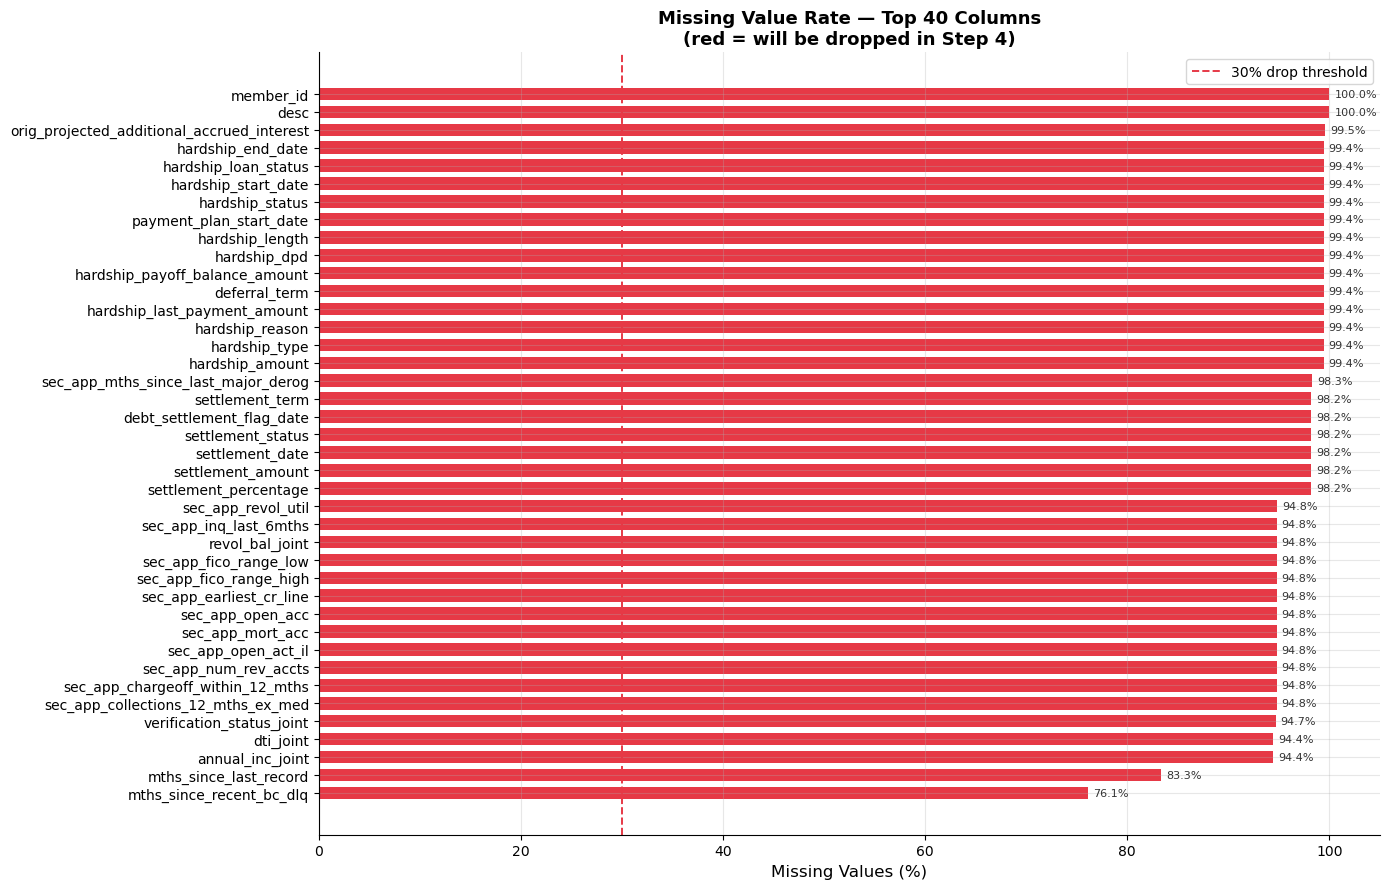

✅  Chart saved as missing_values_chart.png


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 3C — Visualise top 40 columns by missingness
# ─────────────────────────────────────────────────────────────────────────────

top40 = missing_audit[missing_audit['Missing_Pct'] > 0].head(40)

fig, ax = plt.subplots(figsize=(14, 9))

colors = top40['Missing_Pct'].apply(
    lambda p: '#E63946' if p >= 30 else ('#F4A261' if p >= 5 else '#457B9D')
)
bars = ax.barh(top40['Column_Name'], top40['Missing_Pct'], color=colors, edgecolor='none', height=0.7)

ax.axvline(30, color='#E63946', linewidth=1.4, linestyle='--', label='30% drop threshold')
ax.set_xlabel('Missing Values (%)', fontsize=12)
ax.set_title('Missing Value Rate — Top 40 Columns\n(red = will be dropped in Step 4)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.legend(fontsize=10)

for bar, pct in zip(bars, top40['Missing_Pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=8, color='#333333')

plt.tight_layout()
plt.savefig('missing_values_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅  Chart saved as missing_values_chart.png')

---
## Step 4 — Calculate Missingness % and Drop Columns Above 30%
Any column with more than 30% missing values is dropped.  
For this dataset, that removes ~50 columns (mostly hardship, settlement, secondary-applicant, and joint fields).

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 4A — Identify columns above the 30% threshold
# ─────────────────────────────────────────────────────────────────────────────

MISS_THRESHOLD = 30.0   # percentage threshold

miss_pct_series = (df.isnull().sum() / len(df) * 100)

cols_to_drop_miss  = miss_pct_series[miss_pct_series >= MISS_THRESHOLD].index.tolist()
cols_to_keep_miss  = miss_pct_series[miss_pct_series <  MISS_THRESHOLD].index.tolist()

print(f'Missing threshold       : {MISS_THRESHOLD}%')
print(f'Columns to DROP (>= 30%): {len(cols_to_drop_miss)}')
print(f'Columns to KEEP (< 30%) : {len(cols_to_keep_miss)}')
print()

# Show the dropped columns with their missingness rates
dropped_miss_df = (
    miss_pct_series[cols_to_drop_miss]
    .sort_values(ascending=False)
    .rename('Missing_%')
    .reset_index()
    .rename(columns={'index': 'Column_Name'})
)
dropped_miss_df['Missing_%'] = dropped_miss_df['Missing_%'].map('{:.1f}%'.format)

print('── Columns being dropped (>= 30% missing) ───────────────────────────')
display(dropped_miss_df)

Missing threshold       : 30.0%
Columns to DROP (>= 30%): 58
Columns to KEEP (< 30%) : 93

── Columns being dropped (>= 30% missing) ───────────────────────────


,Column_Name,Missing_%
0,member_id,100.0%
1,desc,100.0%
2,orig_projected_additional_accrued_interest,99.5%
3,hardship_length,99.4%
4,hardship_type,99.4%
5,hardship_reason,99.4%
6,hardship_status,99.4%
7,deferral_term,99.4%
8,hardship_amount,99.4%
9,hardship_start_date,99.4%


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 4B — Apply the drop
# ─────────────────────────────────────────────────────────────────────────────

df = df.drop(columns=cols_to_drop_miss)

print(f'✅  High-missingness columns dropped.')
print(f'    Columns before : {raw_df.shape[1]}')
print(f'    Columns after  : {df.shape[1]}')
print(f'    Rows unchanged : {df.shape[0]:,}')

✅  High-missingness columns dropped.
    Columns before : 151
    Columns after  : 93
    Rows unchanged : 1,048,575


---
## Step 5 — Keep Only the 34 Useful Variables
After the missingness drop, we apply a final column selection to retain exactly the 34 variables identified in the project proposal as analytically relevant and free of data leakage.

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 5A — Define the 34 variables to keep (professional names, post-rename)
# ─────────────────────────────────────────────────────────────────────────────

KEEP_COLS = [
    # Target
    'Loan_Status',

    # Loan characteristics
    'Loan_Amount',
    'Funded_Amount',
    'Loan_Term',
    'Interest_Rate',
    'Monthly_Installment',
    'Credit_Grade',
    'Credit_Sub_Grade',
    'Loan_Purpose',
    'Initial_Listing_Status',

    # Borrower financial profile
    'Annual_Income',
    'Debt_To_Income_Ratio',
    'Employment_Length',
    'Home_Ownership',
    'Income_Verification_Status',
    'Application_Type',

    # Credit history
    'FICO_Score',
    'Delinquencies_Last_2_Years',
    'Credit_Inquiries_Last_6_Months',
    'Open_Credit_Lines',
    'Public_Derogatory_Records',
    'Revolving_Balance',
    'Revolving_Utilisation_Rate',
    'Total_Credit_Lines',
    'Earliest_Credit_Line_Date',
    'Public_Record_Bankruptcies',

    # Extended credit metrics
    'Accounts_Opened_Last_24_Months',
    'Average_Current_Balance',
    'Bankcard_Utilisation_Rate',
    'Total_Current_Balance',
    'Total_High_Credit_Limit',
    'Pct_Tradelines_Never_Delinquent',
    'Total_Revolving_Accounts',
    'Mortgage_Accounts',
    'Accounts_90_Days_Late_Last_24M',
    'Accounts_Ever_120_Days_Late',
]

print(f'Target variables to keep: {len(KEEP_COLS)}')

# Safety check — confirm all 34 names exist in the current df
missing_from_df = [c for c in KEEP_COLS if c not in df.columns]
if missing_from_df:
    print(f'  The following names are NOT in df — check Step 2 rename:')
    print(missing_from_df)
else:
    print(' All 34 variable names confirmed present in df.')

Target variables to keep: 36
✅  All 34 variable names confirmed present in df.


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 5B — Filter to target loans and apply column selection
# ─────────────────────────────────────────────────────────────────────────────

# Filter rows: keep only completed loans (Fully Paid or Charged Off / Default)
VALID_STATUSES = ['Fully Paid', 'Charged Off', 'Default']
rows_before = len(df)

df = df[df['Loan_Status'].isin(VALID_STATUSES)].copy()
rows_after = len(df)

print(f'── Row filter: keep only completed loans ─────────────────────────────')
print(f'   Rows before filter : {rows_before:,}')
print(f'   Rows kept          : {rows_after:,}')
print(f'   Rows removed       : {rows_before - rows_after:,}  (Current / Late / Grace Period)')
print()

# Column selection — keep exactly the 34 variables
cols_before = df.shape[1]
df = df[KEEP_COLS].copy()

print(f'── Column selection ──────────────────────────────────────────────────')
print(f'   Columns before selection : {cols_before}')
print(f'   Columns after  selection : {df.shape[1]}')
print()
print(f'✅  df now contains {df.shape[0]:,} rows × {df.shape[1]} columns.')

print()
print('── Loan_Status distribution after filtering ──────────────────────────')
status_counts = df['Loan_Status'].value_counts()
status_pct    = (status_counts / len(df) * 100).round(2)
display(
    pd.DataFrame({'Count': status_counts, 'Pct (%)': status_pct})
)

── Row filter: keep only completed loans ─────────────────────────────
   Rows before filter : 1,048,575
   Rows kept          : 611,803
   Rows removed       : 436,772  (Current / Late / Grace Period)

── Column selection ──────────────────────────────────────────────────
   Columns before selection : 93
   Columns after  selection : 36

✅  df now contains 611,803 rows × 36 columns.

── Loan_Status distribution after filtering ──────────────────────────


,Count,Pct (%)
Loan_Status,,
Fully Paid,482595,78.8800
Charged Off,129187,21.1200
Default,21,0.0000


---
## Step 6 — Handle Remaining NaN Values
With 34 columns selected, we apply a two-part strategy:
- **Drop rows** where any genuinely critical feature is missing (e.g. FICO score, DTI, Income).
- **Fill NaN with 0** for columns where zero is a meaningful value (e.g. delinquency counts, bankruptcy counts — NaN here means 'none on record').

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 6A — Audit remaining missingness in the 34 selected variables
# ─────────────────────────────────────────────────────────────────────────────

remaining_miss = (
    pd.DataFrame({
        'Missing_Count': df.isnull().sum(),
        'Missing_Pct'  : (df.isnull().sum() / len(df) * 100).round(3),
    })
    .sort_values('Missing_Pct', ascending=False)
    .reset_index()
    .rename(columns={'index': 'Column_Name'})
)

print('── Remaining missingness in the 34 selected variables ────────────────')
display(remaining_miss)

print(f'\nTotal remaining NaN cells: {df.isnull().sum().sum():,}')

── Remaining missingness in the 34 selected variables ────────────────


,Column_Name,Missing_Count,Missing_Pct
0,Employment_Length,38560,6.3030
1,Bankcard_Utilisation_Rate,6904,1.1280
2,Revolving_Utilisation_Rate,326,0.0530
3,Debt_To_Income_Ratio,218,0.0360
4,Average_Current_Balance,5,0.0010
5,Accounts_Opened_Last_24_Months,0,0.0000
6,Revolving_Balance,0,0.0000
7,Total_Credit_Lines,0,0.0000
8,Earliest_Credit_Line_Date,0,0.0000
9,Public_Record_Bankruptcies,0,0.0000



Total remaining NaN cells: 46,015


In [37]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 6B — Encode NaNs as 0 for count / ratio columns
#  (NaN in these columns means 'no occurrence on record')
# ─────────────────────────────────────────────────────────────────────────────

FILL_ZERO_COLS = [
    'Bankcard_Utilisation_Rate',          # NaN = no bankcard accounts (treat as 0%)
    'Revolving_Utilisation_Rate',         # NaN = no revolving accounts
    'Accounts_90_Days_Late_Last_24M',     # NaN = no accounts (0 occurrences)
    'Accounts_Ever_120_Days_Late',        # NaN = no accounts (0 occurrences)
    'Mortgage_Accounts',                  # NaN = no mortgage (0 mortgages)
    'Public_Record_Bankruptcies',         # NaN = no bankruptcies on record
    'Pct_Tradelines_Never_Delinquent',    # NaN = no tradelines (treat as 0%)
    'Average_Current_Balance',            # NaN = no open accounts (0 balance)
]

# Only fill columns that actually exist in df
fill_present = [c for c in FILL_ZERO_COLS if c in df.columns]

before_nulls = df[fill_present].isnull().sum().sum()
df[fill_present] = df[fill_present].fillna(0)
after_nulls  = df[fill_present].isnull().sum().sum()

print(f'── NaN → 0 encoding ──────────────────────────────────────────────────')
print(f'   Columns processed : {len(fill_present)}')
print(f'   NaNs before       : {before_nulls:,}')
print(f'   NaNs after        : {after_nulls:,}')
print(f'   NaNs filled       : {before_nulls - after_nulls:,}')

── NaN → 0 encoding ──────────────────────────────────────────────────
   Columns processed : 8
   NaNs before       : 7,236
   NaNs after        : 0
   NaNs filled       : 7,236


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 6C — Drop remaining rows with any NaN
#  (after zero-filling, only critical columns like DTI / Income / FICO may
#   have a small number of NaN rows — drop these rather than impute)
# ─────────────────────────────────────────────────────────────────────────────

rows_before_drop = len(df)
nulls_before     = df.isnull().sum().sum()

# Show which columns still have NaN before dropping
still_null = df.isnull().sum()
still_null = still_null[still_null > 0]
if len(still_null) > 0:
    print('── Columns still containing NaN (to be dropped via row removal) ─────')
    display(still_null.rename('NaN_Count').reset_index().rename(columns={'index':'Column'}))
else:
    print('No remaining NaN values — row drop not needed.')

df = df.dropna()

rows_after_drop = len(df)
nulls_after     = df.isnull().sum().sum()

print(f'\n── Row drop summary ──────────────────────────────────────────────────')
print(f'   Rows before : {rows_before_drop:,}')
print(f'   Rows after  : {rows_after_drop:,}')
print(f'   Rows dropped: {rows_before_drop - rows_after_drop:,}')
print(f'   NaN cells remaining: {nulls_after}  ← should be 0')
print(f'\n✅  df is now fully clean: {df.shape[0]:,} rows × {df.shape[1]} columns.')

── Columns still containing NaN (to be dropped via row removal) ─────


,Column,NaN_Count
0,Debt_To_Income_Ratio,218
1,Employment_Length,38560
2,Total_Revolving_Accounts,1



── Row drop summary ──────────────────────────────────────────────────
   Rows before : 611,803
   Rows after  : 573,236
   Rows dropped: 38,567
   NaN cells remaining: 0  ← should be 0

✅  df is now fully clean: 573,236 rows × 36 columns.


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 6D — Final confirmation: zero missing values
# ─────────────────────────────────────────────────────────────────────────────

final_miss = df.isnull().sum().sum()

print('── Final missing-value check ─────────────────────────────────────────')
print(f'   Total NaN / NA / missing cells: {final_miss}')

if final_miss == 0:
    print('    Dataset is complete — no missing values.')
else:
    print('      Unexpected NaNs remain — re-check Steps 6B and 6C.')

# Confirm Loan_Status distribution after all cleaning
print()
print('── Loan_Status distribution after full cleaning ──────────────────────')
status_final = df['Loan_Status'].value_counts()
status_final_pct = (status_final / len(df) * 100).round(2)
display(pd.DataFrame({'Count': status_final, 'Pct (%)': status_final_pct}))

── Final missing-value check ─────────────────────────────────────────
   Total NaN / NA / missing cells: 0
    Dataset is complete — no missing values.

── Loan_Status distribution after full cleaning ──────────────────────


,Count,Pct (%)
Loan_Status,,
Fully Paid,454672,79.3200
Charged Off,118544,20.6800
Default,20,0.0000


---
## Step 7 — Summary Statistics for the 34 Selected Variables
We produce four distinct summary tables: numeric descriptive stats, categorical frequency counts, a variable schema overview, and a correlation heatmap for numeric features.

In [46]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 7A — Variable schema overview (name, dtype, unique values, sample)
# ─────────────────────────────────────────────────────────────────────────────

schema = pd.DataFrame({
    'Column'       : df.columns,
    'Dtype'        : df.dtypes.values,
    'Unique_Values': [df[c].nunique() for c in df.columns],
    'Sample_Value' : [str(df[c].dropna().iloc[0]) if len(df[c].dropna()) > 0 else 'N/A'
                      for c in df.columns],
    'Missing_Count': df.isnull().sum().values,
})

print('── Variable Schema Overview ──────────────────────────────────────────')
display(schema)

── Variable Schema Overview ──────────────────────────────────────────


,Column,Dtype,Unique_Values,Sample_Value,Missing_Count
0,Loan_Status,object,3,Fully Paid,0
1,Loan_Amount,float64,1518,3600.0,0
2,Funded_Amount,float64,1518,3600.0,0
3,Loan_Term,object,2,36 months,0
4,Interest_Rate,float64,265,13.99,0
5,Monthly_Installment,float64,55435,123.03,0
6,Credit_Grade,object,7,C,0
7,Credit_Sub_Grade,object,35,C4,0
8,Loan_Purpose,object,14,debt_consolidation,0
9,Initial_Listing_Status,object,2,w,0


In [48]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 7B — Numeric descriptive statistics (extended)
# ─────────────────────────────────────────────────────────────────────────────

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

numeric_stats = df[numeric_cols].describe(percentiles=[.05, .25, .50, .75, .95]).T
numeric_stats['skewness'] = df[numeric_cols].skew().round(4)
numeric_stats['kurtosis'] = df[numeric_cols].kurtosis().round(4)
numeric_stats = numeric_stats.round(4)

print(f'── Numeric Variables: Descriptive Statistics ({len(numeric_cols)} columns) ──────')
display(numeric_stats)

── Numeric Variables: Descriptive Statistics (25 columns) ──────


,count,mean,std,min,5%,25%,50%,75%,95%,max,skewness,kurtosis
Loan_Amount,"573,236.0000","14,762.8864","8,842.4439","1,000.0000","3,500.0000","8,000.0000","12,500.0000","20,000.0000","34,800.0000","40,000.0000",0.7492,-0.1765
Funded_Amount,"573,236.0000","14,762.8864","8,842.4439","1,000.0000","3,500.0000","8,000.0000","12,500.0000","20,000.0000","34,800.0000","40,000.0000",0.7492,-0.1765
Interest_Rate,"573,236.0000",12.7058,4.7954,5.3100,6.2400,9.1700,12.2900,15.5900,21.4500,30.9900,0.8514,0.8461
Monthly_Installment,"573,236.0000",444.7539,264.4741,14.0100,114.2500,251.7675,378.1500,593.3200,978.7400,"1,719.8300",0.9931,0.6674
Annual_Income,"573,236.0000","78,716.6126","75,656.7976",33.0000,"30,000.0000","48,000.0000","66,000.0000","94,000.0000","160,000.0000","10,999,200.0000",49.8586,"5,092.0821"
Debt_To_Income_Ratio,"573,236.0000",18.7780,9.9129,-1.0000,5.2100,12.1300,18.0800,24.8000,34.0500,999.0000,13.4045,"1,122.4682"
FICO_Score,"573,236.0000",695.4211,31.7079,660.0000,660.0000,670.0000,690.0000,710.0000,760.0000,845.0000,1.3166,1.7835
Delinquencies_Last_2_Years,"573,236.0000",0.3437,0.9287,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,39.0000,5.5581,58.0921
Credit_Inquiries_Last_6_Months,"573,236.0000",0.5829,0.8732,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,6.0000,1.7695,3.5309
Open_Credit_Lines,"573,236.0000",11.9306,5.7006,0.0000,5.0000,8.0000,11.0000,15.0000,23.0000,90.0000,1.3035,3.3350


In [52]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 7C — Categorical variable frequency tables
# ─────────────────────────────────────────────────────────────────────────────

cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'── Categorical Variables: Frequency Counts ({len(cat_cols)} columns) ──────────')
for col in cat_cols:
    vc  = df[col].value_counts(dropna=False)
    pct = (vc / len(df) * 100).round(2)
    freq_table = pd.DataFrame({'Count': vc, 'Pct (%)': pct}).reset_index()
    freq_table.columns = [col, 'Count', 'Pct (%)']
    print(f'\n  {col}')
    display(freq_table.head(20))   # show up to 20 categories

── Categorical Variables: Frequency Counts (11 columns) ──────────

  Loan_Status


,Loan_Status,Count,Pct (%)
0,Fully Paid,454672,79.3200
1,Charged Off,118544,20.6800
2,Default,20,0.0000



  Loan_Term


,Loan_Term,Count,Pct (%)
0,36 months,433787,75.6700
1,60 months,139449,24.3300



  Credit_Grade


...

,Income_Verification_Status,Count,Pct (%)
0,Source Verified,254273,44.3600
1,Not Verified,169475,29.5600
2,Verified,149488,26.0800



  Application_Type


,Application_Type,Count,Pct (%)
0,Individual,561866,98.0200
1,Joint App,11370,1.9800



  Earliest_Credit_Line_Date


,Earliest_Credit_Line_Date,Count,Pct (%)
0,Sep-04,4370,0.7600
1,Aug-02,4293,0.7500
2,Sep-03,4290,0.7500
3,Aug-03,4103,0.7200
4,Aug-01,4103,0.7200
5,Aug-04,4062,0.7100
6,Sep-02,4047,0.7100
7,Oct-03,3879,0.6800
8,Oct-01,3783,0.6600
9,Sep-05,3770,0.6600


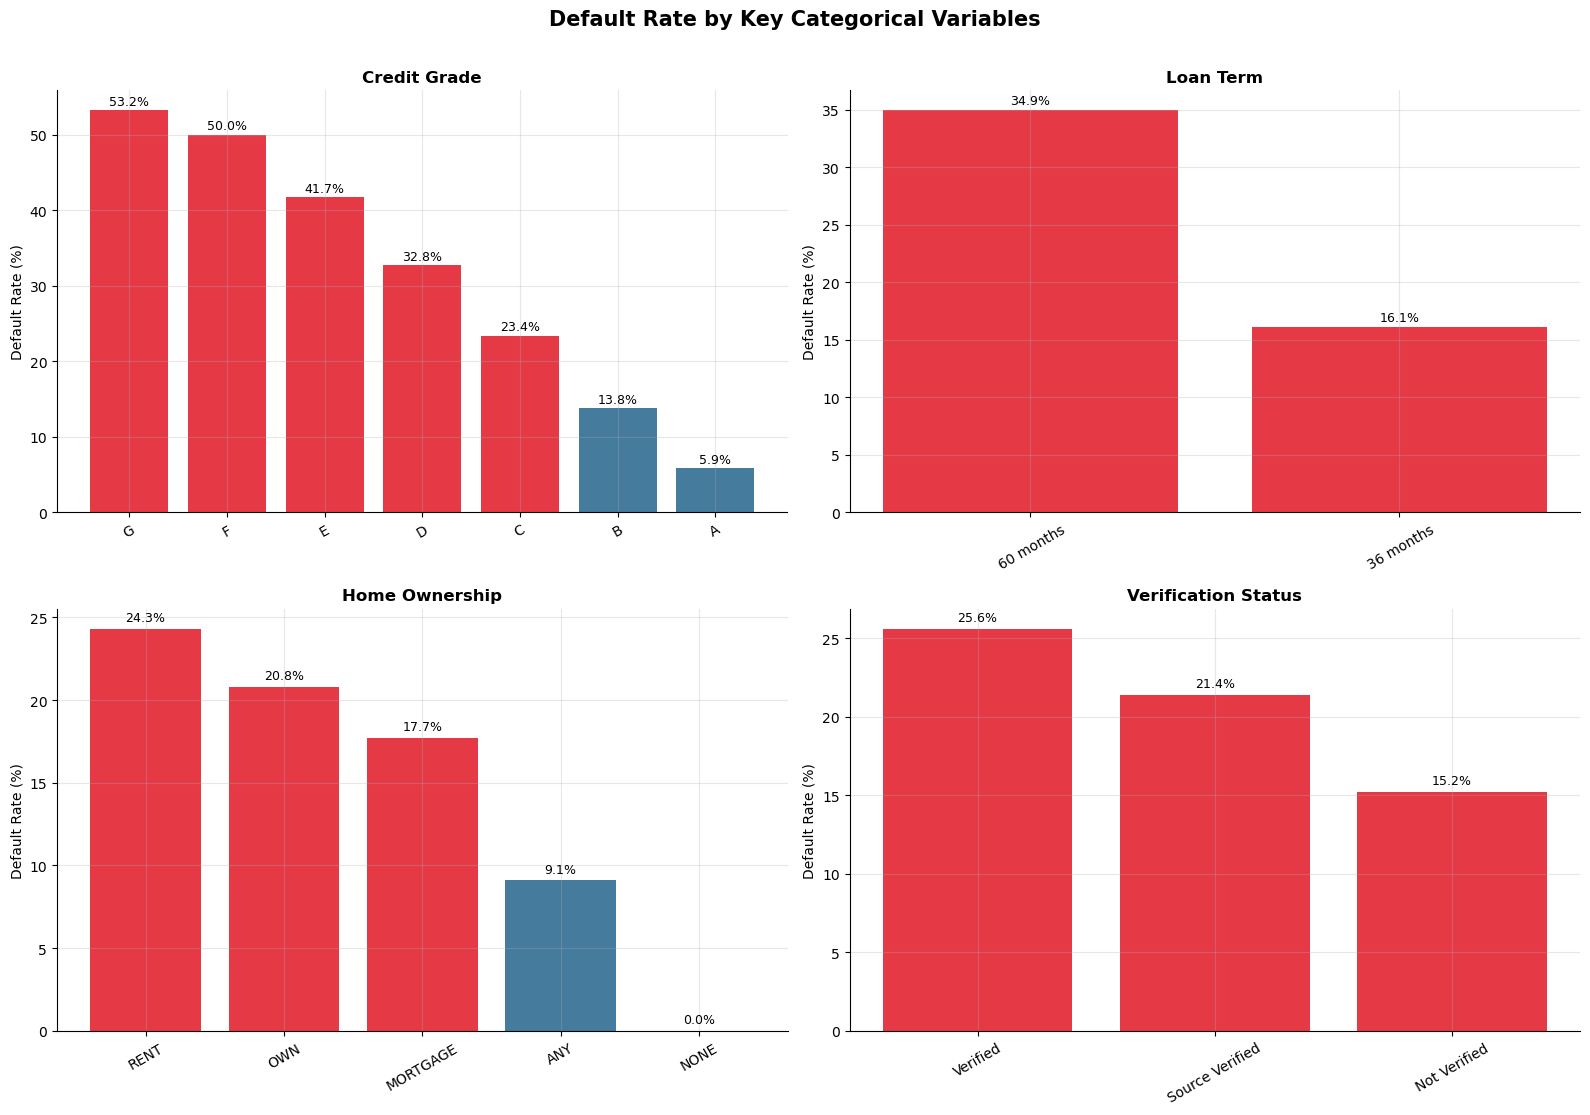

✅  Chart saved as default_rate_by_category.png


In [54]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 7D — Default rate by key categorical variables
# ─────────────────────────────────────────────────────────────────────────────

# Create a temporary binary label for the visualisation only
df['_default'] = df['Loan_Status'].isin(['Charged Off', 'Default']).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Default Rate by Key Categorical Variables', fontsize=15, fontweight='bold', y=1.01)

plot_cats = [
    ('Credit_Grade',              'Credit Grade'),
    ('Loan_Term',                 'Loan Term'),
    ('Home_Ownership',            'Home Ownership'),
    ('Income_Verification_Status','Verification Status'),
]

for ax, (col, label) in zip(axes.flatten(), plot_cats):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    dr = (df.groupby(col)['_default'].mean() * 100).sort_values(ascending=False)
    bars = ax.bar(dr.index.astype(str), dr.values,
                  color=['#E63946' if v > 15 else '#457B9D' for v in dr.values],
                  edgecolor='none')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Default Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('default_rate_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅  Chart saved as default_rate_by_category.png')

# Remove temporary column
df = df.drop(columns=['_default'])

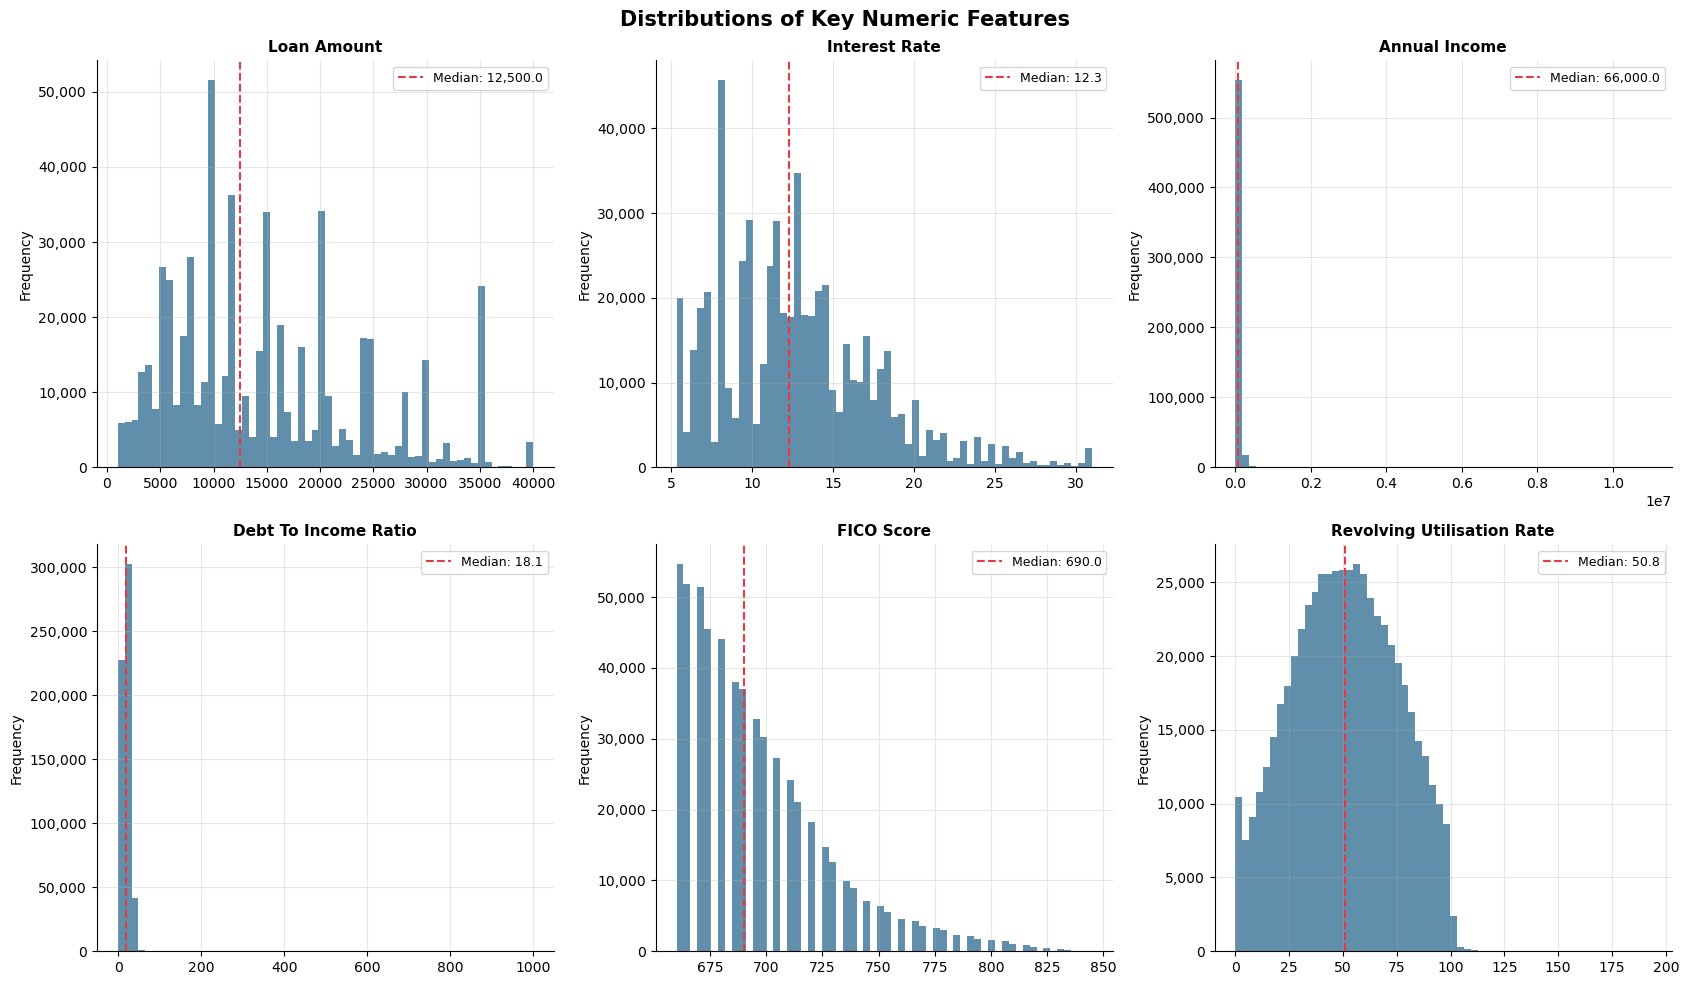

✅  Chart saved as numeric_distributions.png


In [58]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 7E — Distribution plots for key numeric features
# ─────────────────────────────────────────────────────────────────────────────

PLOT_NUMERIC = [
    'Loan_Amount', 'Interest_Rate', 'Annual_Income',
    'Debt_To_Income_Ratio', 'FICO_Score', 'Revolving_Utilisation_Rate',
]

plot_cols = [c for c in PLOT_NUMERIC if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Distributions of Key Numeric Features', fontsize=15, fontweight='bold')

for ax, col in zip(axes.flatten(), plot_cols):
    data = df[col].dropna()
    ax.hist(data, bins=60, color='#457B9D', edgecolor='none', alpha=0.85)
    ax.axvline(data.median(), color='#E63946', linewidth=1.5,
               linestyle='--', label=f'Median: {data.median():,.1f}')
    ax.set_title(col.replace('_', ' '), fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅  Chart saved as numeric_distributions.png')

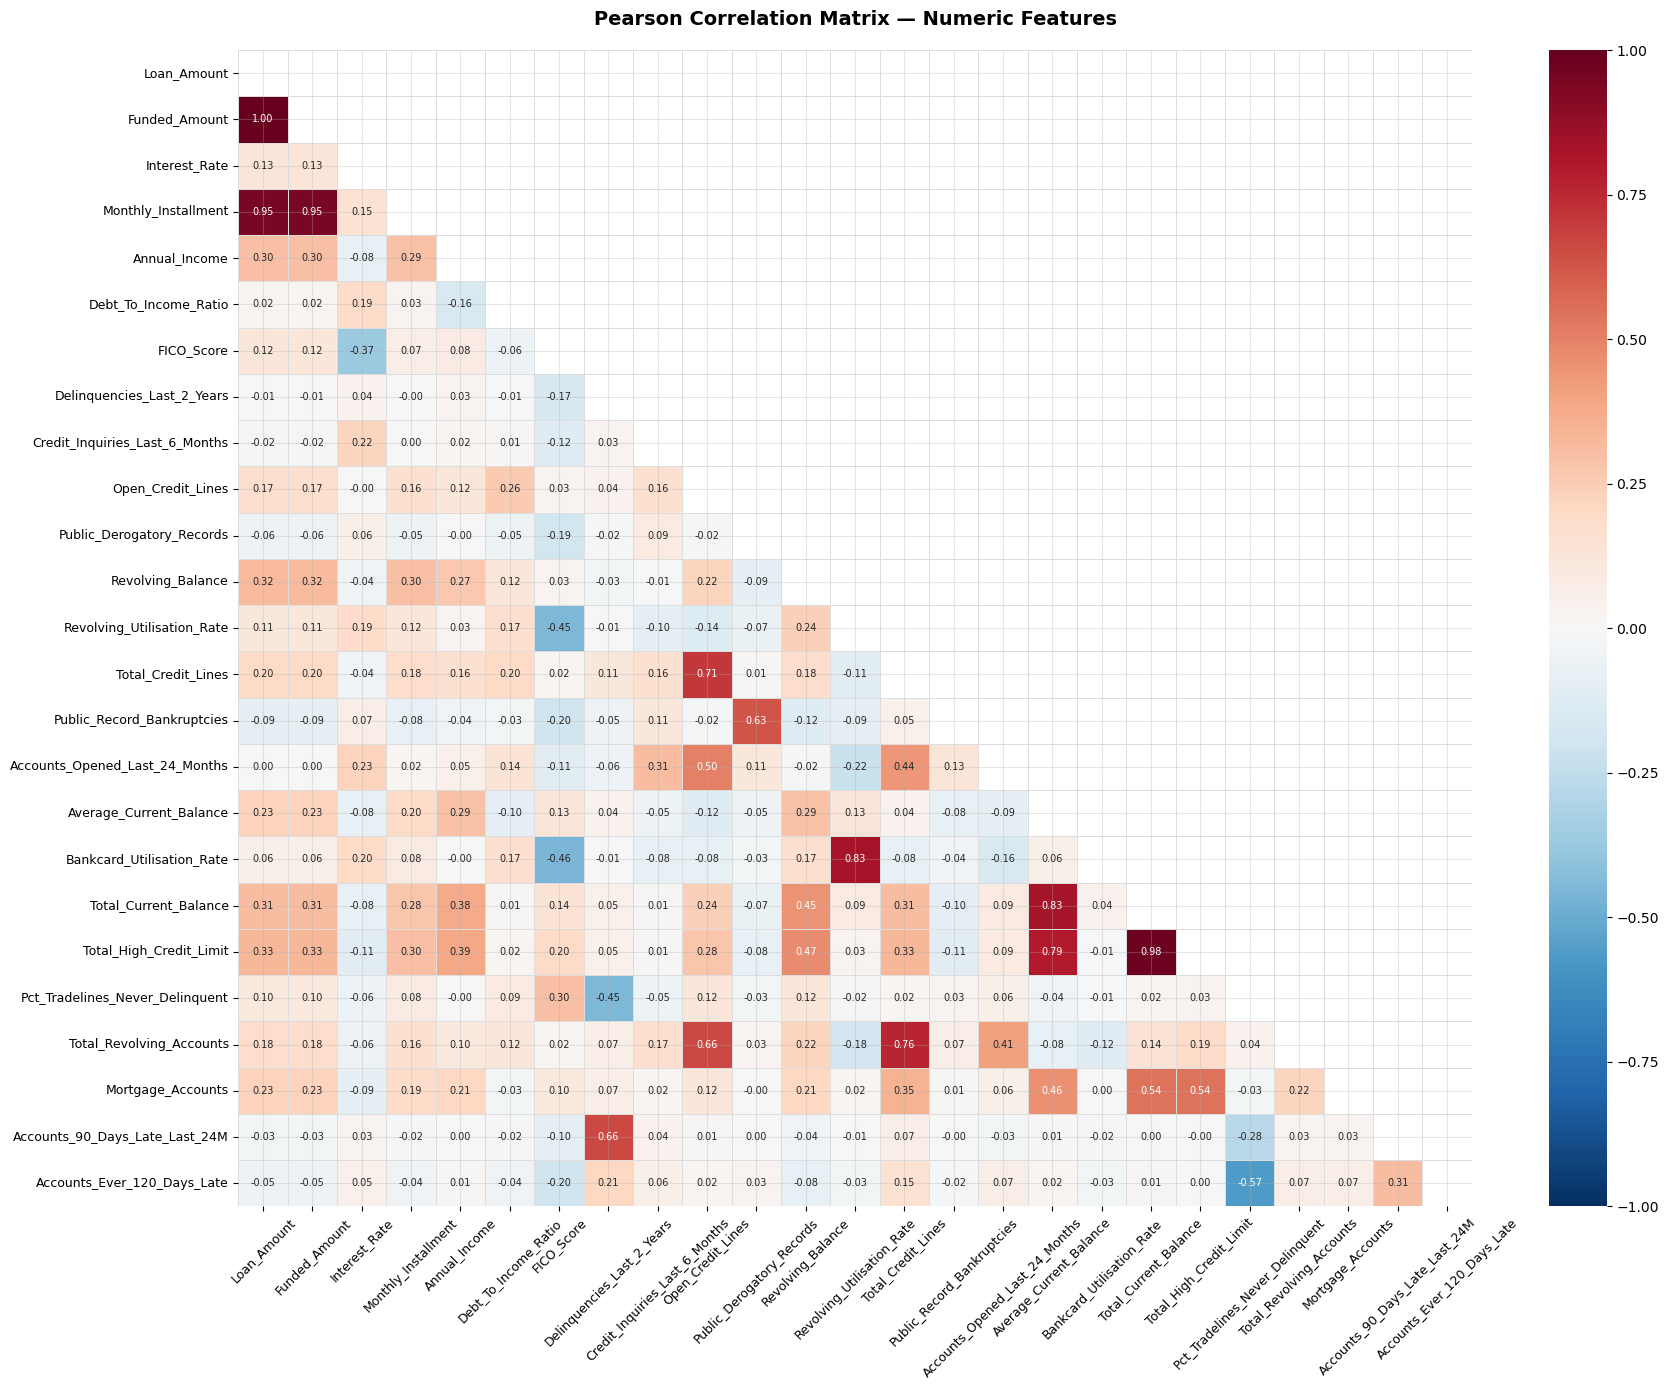

✅  Chart saved as correlation_heatmap.png


In [60]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 7F — Correlation heatmap for numeric variables
# ─────────────────────────────────────────────────────────────────────────────

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix  = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask       = mask,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'RdBu_r',
    center     = 0,
    vmin       = -1, vmax = 1,
    linewidths = 0.4,
    linecolor  = '#DDDDDD',
    annot_kws  = {'size': 7},
    ax         = ax,
)

ax.set_title('Pearson Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold', pad=18)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅  Chart saved as correlation_heatmap.png')

In [62]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 7G — High-correlation pairs (|r| >= 0.70)
# ─────────────────────────────────────────────────────────────────────────────

corr_pairs = (
    corr_matrix
    .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Variable_A', 'Variable_B', 'Pearson_r']
corr_pairs['Abs_r'] = corr_pairs['Pearson_r'].abs()
high_corr = corr_pairs[corr_pairs['Abs_r'] >= 0.70].sort_values('Abs_r', ascending=False)

print(f'── Highly correlated variable pairs (|r| >= 0.70) ────────────────────')
if len(high_corr) == 0:
    print('   None found.')
else:
    display(high_corr.reset_index(drop=True))
    print(f'\n   ⚠️   Consider checking these pairs for multicollinearity in logistic regression baseline.')

── Highly correlated variable pairs (|r| >= 0.70) ────────────────────


,Variable_A,Variable_B,Pearson_r,Abs_r
0,Funded_Amount,Loan_Amount,1.0000,1.0000
1,Total_High_Credit_Limit,Total_Current_Balance,0.9800,0.9800
2,Monthly_Installment,Loan_Amount,0.9500,0.9500
3,Monthly_Installment,Funded_Amount,0.9500,0.9500
4,Bankcard_Utilisation_Rate,Revolving_Utilisation_Rate,0.8300,0.8300
5,Total_Current_Balance,Average_Current_Balance,0.8300,0.8300
6,Total_High_Credit_Limit,Average_Current_Balance,0.7900,0.7900
7,Total_Revolving_Accounts,Total_Credit_Lines,0.7600,0.7600
8,Total_Credit_Lines,Open_Credit_Lines,0.7100,0.7100



   ⚠️   Consider checking these pairs for multicollinearity in logistic regression baseline.


---
## Step 8 — Save the Cleaned Dataset as `cleaned_df`
The final cleaned dataset is assigned to `cleaned_df` and saved as a CSV file for use in subsequent modelling notebooks.

In [64]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 8A — Assign to cleaned_df and final verification
# ─────────────────────────────────────────────────────────────────────────────

cleaned_df = df.copy()

print('━' * 60)
print('  FINAL CLEANED DATASET — SUMMARY')
print('━' * 60)
print(f'  Variable name        : cleaned_df')
print(f'  Rows                 : {cleaned_df.shape[0]:,}')
print(f'  Columns              : {cleaned_df.shape[1]}')
print(f'  Total cells          : {cleaned_df.size:,}')
print(f'  Missing values       : {cleaned_df.isnull().sum().sum()}')
print(f'  Memory usage         : {cleaned_df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print('━' * 60)

print()
print('── Target variable distribution ──────────────────────────────────────')
target_dist = cleaned_df['Loan_Status'].value_counts()
target_pct  = (target_dist / len(cleaned_df) * 100).round(2)
display(pd.DataFrame({'Count': target_dist, 'Pct (%)': target_pct}))

print()
print('── Column list ───────────────────────────────────────────────────────')
for i, col in enumerate(cleaned_df.columns, 1):
    print(f'   {i:>2}. {col}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FINAL CLEANED DATASET — SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Variable name        : cleaned_df
  Rows                 : 573,236
  Columns              : 36
  Total cells          : 20,636,496
  Missing values       : 0
  Memory usage         : 474.6 MB
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── Target variable distribution ──────────────────────────────────────


,Count,Pct (%)
Loan_Status,,
Fully Paid,454672,79.3200
Charged Off,118544,20.6800
Default,20,0.0000



── Column list ───────────────────────────────────────────────────────
    1. Loan_Status
    2. Loan_Amount
    3. Funded_Amount
    4. Loan_Term
    5. Interest_Rate
    6. Monthly_Installment
    7. Credit_Grade
    8. Credit_Sub_Grade
    9. Loan_Purpose
   10. Initial_Listing_Status
   11. Annual_Income
   12. Debt_To_Income_Ratio
   13. Employment_Length
   14. Home_Ownership
   15. Income_Verification_Status
   16. Application_Type
   17. FICO_Score
   18. Delinquencies_Last_2_Years
   19. Credit_Inquiries_Last_6_Months
   20. Open_Credit_Lines
   21. Public_Derogatory_Records
   22. Revolving_Balance
   23. Revolving_Utilisation_Rate
   24. Total_Credit_Lines
   25. Earliest_Credit_Line_Date
   26. Public_Record_Bankruptcies
   27. Accounts_Opened_Last_24_Months
   28. Average_Current_Balance
   29. Bankcard_Utilisation_Rate
   30. Total_Current_Balance
   31. Total_High_Credit_Limit
   32. Pct_Tradelines_Never_Delinquent
   33. Total_Revolving_Accounts
   34. Mortgage_Account

In [66]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 8B — Save to CSV
# ─────────────────────────────────────────────────────────────────────────────

OUTPUT_FILE = 'cleaned_df.csv'

cleaned_df.to_csv(OUTPUT_FILE, index=False)

file_size_mb = os.path.getsize(OUTPUT_FILE) / 1e6

print(f'  Cleaned dataset saved.')
print(f'   File name  : {OUTPUT_FILE}')
print(f'   File size  : {file_size_mb:.1f} MB')
print(f'   Rows saved : {len(cleaned_df):,}')
print(f'   Cols saved : {cleaned_df.shape[1]}')

✅  Cleaned dataset saved.
   File name  : cleaned_df.csv
   File size  : 134.4 MB
   Rows saved : 573,236
   Cols saved : 36


In [70]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 8C — Download the file (Google Colab only)
# ─────────────────────────────────────────────────────────────────────────────

if ENV == 'colab':
    from google.colab import files
    files.download(OUTPUT_FILE)
    print('  Download triggered in Colab.')
else:
    print(f'  File saved locally at: {os.path.abspath(OUTPUT_FILE)}')

  File saved locally at: C:\Users\ikadd\cleaned_df.csv


In [74]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 8D — Reload and verify the saved file
# ─────────────────────────────────────────────────────────────────────────────

verify_df = pd.read_csv(OUTPUT_FILE)

print('── Verification: reloaded file ───────────────────────────────────────')
print(f'   Shape   : {verify_df.shape}')
print(f'   Columns : {list(verify_df.columns)}')
print(f'   Missing : {verify_df.isnull().sum().sum()}')
print()
display(verify_df.head(5))

print()
print('━' * 60)
print('    ALL PREPROCESSING STEPS COMPLETE')
print('━' * 60)
print('  cleaned_df is ready for:')
print('  → Week 3: Feature Engineering') 
print('  → Week 4: Logistic Regression & Random Forest baselines')
print('  → Week 5: Feedforward Neural Network training')
print('━' * 60)

── Verification: reloaded file ───────────────────────────────────────
   Shape   : (573236, 36)
   Columns : ['Loan_Status', 'Loan_Amount', 'Funded_Amount', 'Loan_Term', 'Interest_Rate', 'Monthly_Installment', 'Credit_Grade', 'Credit_Sub_Grade', 'Loan_Purpose', 'Initial_Listing_Status', 'Annual_Income', 'Debt_To_Income_Ratio', 'Employment_Length', 'Home_Ownership', 'Income_Verification_Status', 'Application_Type', 'FICO_Score', 'Delinquencies_Last_2_Years', 'Credit_Inquiries_Last_6_Months', 'Open_Credit_Lines', 'Public_Derogatory_Records', 'Revolving_Balance', 'Revolving_Utilisation_Rate', 'Total_Credit_Lines', 'Earliest_Credit_Line_Date', 'Public_Record_Bankruptcies', 'Accounts_Opened_Last_24_Months', 'Average_Current_Balance', 'Bankcard_Utilisation_Rate', 'Total_Current_Balance', 'Total_High_Credit_Limit', 'Pct_Tradelines_Never_Delinquent', 'Total_Revolving_Accounts', 'Mortgage_Accounts', 'Accounts_90_Days_Late_Last_24M', 'Accounts_Ever_120_Days_Late']
   Missing : 0



,Loan_Status,Loan_Amount,Funded_Amount,Loan_Term,Interest_Rate,Monthly_Installment,Credit_Grade,Credit_Sub_Grade,Loan_Purpose,Initial_Listing_Status,Annual_Income,Debt_To_Income_Ratio,Employment_Length,Home_Ownership,Income_Verification_Status,Application_Type,FICO_Score,Delinquencies_Last_2_Years,Credit_Inquiries_Last_6_Months,Open_Credit_Lines,Public_Derogatory_Records,Revolving_Balance,Revolving_Utilisation_Rate,Total_Credit_Lines,Earliest_Credit_Line_Date,Public_Record_Bankruptcies,Accounts_Opened_Last_24_Months,Average_Current_Balance,Bankcard_Utilisation_Rate,Total_Current_Balance,Total_High_Credit_Limit,Pct_Tradelines_Never_Delinquent,Total_Revolving_Accounts,Mortgage_Accounts,Accounts_90_Days_Late_Last_24M,Accounts_Ever_120_Days_Late
0,Fully Paid,"3,600.0000","3,600.0000",36 months,13.9900,123.0300,C,C4,debt_consolidation,w,"55,000.0000",5.9100,10+ years,MORTGAGE,Not Verified,Individual,675.0000,0.0000,1.0000,7.0000,0.0000,"2,765.0000",29.7000,13.0000,Aug-03,0.0000,4.0000,"20,701.0000",37.2000,"144,904.0000","178,050.0000",76.9000,9.0000,1.0000,0.0000,2.0000
1,Fully Paid,"24,700.0000","24,700.0000",36 months,11.9900,820.2800,C,C1,small_business,w,"65,000.0000",16.0600,10+ years,MORTGAGE,Not Verified,Individual,715.0000,1.0000,4.0000,22.0000,0.0000,"21,470.0000",19.2000,38.0000,Dec-99,0.0000,4.0000,"9,733.0000",27.1000,"204,396.0000","314,017.0000",97.4000,27.0000,4.0000,0.0000,0.0000
2,Fully Paid,"20,000.0000","20,000.0000",60 months,10.7800,432.6600,B,B4,home_improvement,w,"63,000.0000",10.7800,10+ years,MORTGAGE,Not Verified,Joint App,695.0000,0.0000,0.0000,6.0000,0.0000,"7,869.0000",56.2000,18.0000,Aug-00,0.0000,6.0000,"31,617.0000",55.9000,"189,699.0000","218,418.0000",100.0000,7.0000,5.0000,0.0000,0.0000
3,Fully Paid,"10,400.0000","10,400.0000",60 months,22.4500,289.9100,F,F1,major_purchase,w,"104,433.0000",25.3700,3 years,MORTGAGE,Source Verified,Individual,695.0000,1.0000,3.0000,12.0000,0.0000,"21,929.0000",64.5000,35.0000,Jun-98,0.0000,10.0000,"27,644.0000",77.5000,"331,730.0000","439,570.0000",96.6000,19.0000,6.0000,0.0000,0.0000
4,Fully Paid,"11,950.0000","11,950.0000",36 months,13.4400,405.1800,C,C3,debt_consolidation,w,"34,000.0000",10.2000,4 years,RENT,Source Verified,Individual,690.0000,0.0000,0.0000,5.0000,0.0000,"8,822.0000",68.4000,6.0000,Oct-87,0.0000,0.0000,"2,560.0000",91.0000,"12,798.0000","16,900.0000",100.0000,4.0000,0.0000,0.0000,0.0000



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    ALL PREPROCESSING STEPS COMPLETE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  cleaned_df is ready for:
  → Week 3: Feature Engineering
  → Week 4: Logistic Regression & Random Forest baselines
  → Week 5: Feedforward Neural Network training
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
